In [1]:
import sys
sys.path.append("/home/wuhlmann/BA/repo/lamah-ce_lstm/analysis/CSA")

In [2]:
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path

from numpy.random import Generator, MT19937
from collections import Counter 
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, jaccard_score
from sklearn.preprocessing import StandardScaler

#plotting
from matplotlib.patches import Patch, Polygon
import matplotlib.pyplot as plt
import seaborn as sns
from cell_state_plotters import plot_cell_state_2d, plot_cell_state_3d

#### Load data

In [3]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [4]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf["strata_ids"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [5]:
scaler = StandardScaler()

hydro_indices_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/1_attributes/Hydro_indices_1981_2017.csv")

# hy id are used to validate the clusters, which are based on the catchment attributes.
hydro_indices = pd.read_table(hydro_indices_path, header=0, sep=";")
hydro_indices.set_index("ID", inplace=True)

no_na_hy_id = hydro_indices.dropna()
numeric_hy_id = no_na_hy_id.select_dtypes(include=["number"])
scaled_hy_id = pd.DataFrame(
	scaler.fit_transform(numeric_hy_id.values),
	columns=numeric_hy_id.columns,
	index=numeric_hy_id.index
)

In [6]:
with open("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p", "rb") as f: 
	domain_metrics = pickle.load(f)
	
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

### MDS of cell states

In [29]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_mds.p", "rb") as f: 
	means_mds = pickle.load(f)

In [35]:
array = means_mds["non_metric"][2].embedding_

IndexError: index 2 is out of bounds for axis 1 with size 2

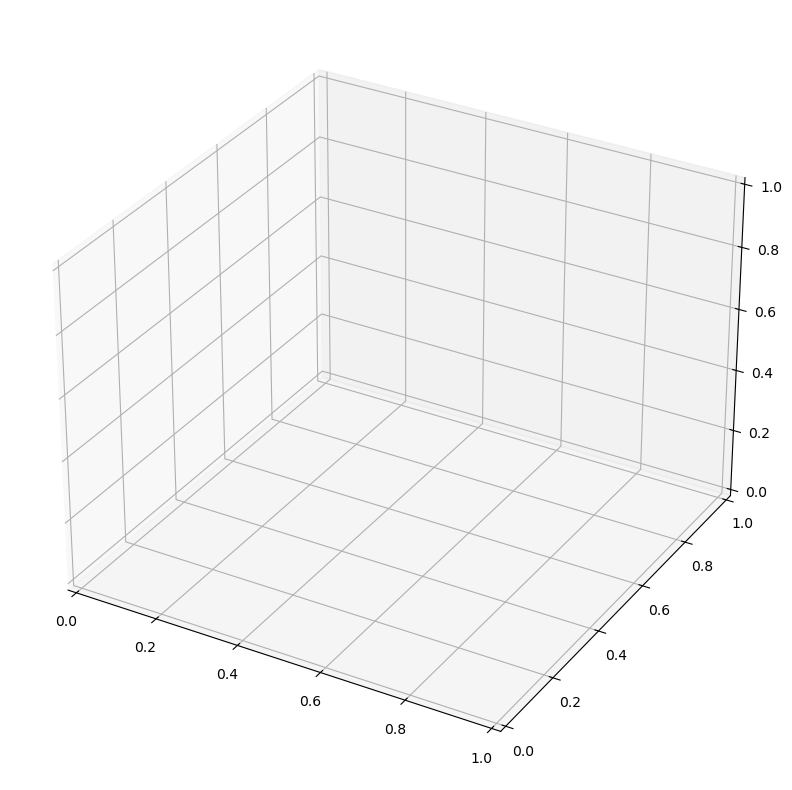

In [12]:
fig, ax = plt.subplots(1,1, figsize=(10,10), subplot_kw={"projection": "3d"})
plot_cell_state_3d(cell_state_array=array, ax=ax)

In [36]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

100%|██████████| 100/100 [00:06<00:00, 16.04it/s]


Text(0.5, 1.0, 's_scores')

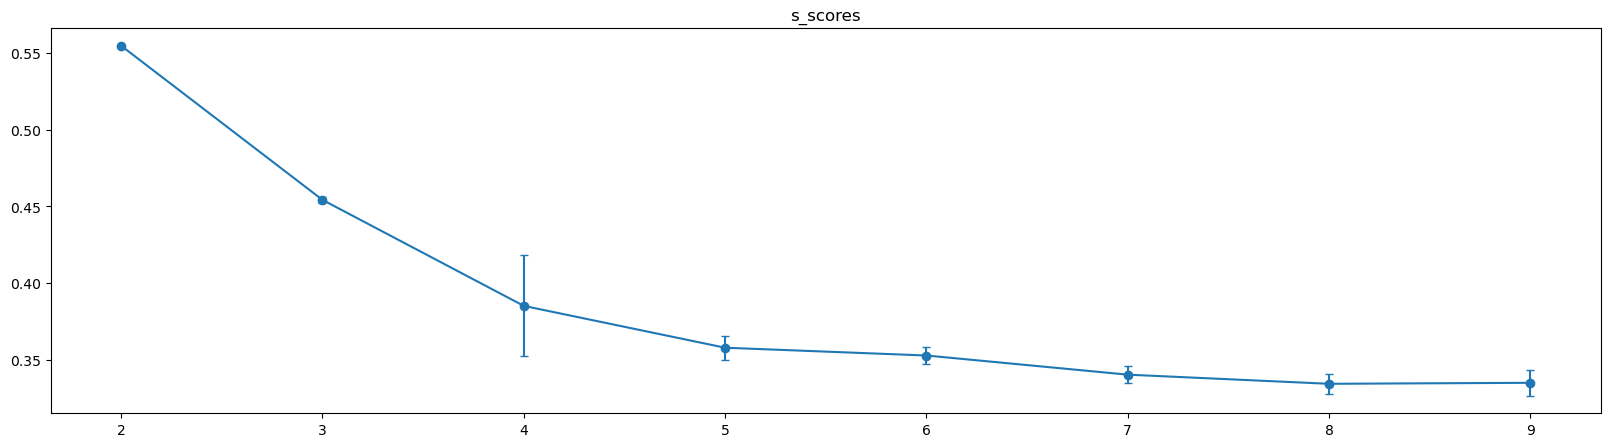

In [37]:
n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(array)
		s_scores[i,k] = silhouette_score(array,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)

axs.set_title("s_scores")

#### Pinpoint basins in mds space

In [ ]:
sep_transition_strata_ids = [759, 771, 740, 752, 670, 830, 822, 824, 823, 825]
positions = [lamah_gdf.index.get_loc(i) for i in sep_transition_strata_ids]
sep_mds_points =  array[positions, :]

In [ ]:
lamah_gdf["mds1"] = array[:,0]
lamah_gdf["mds2"] = array[:,1]

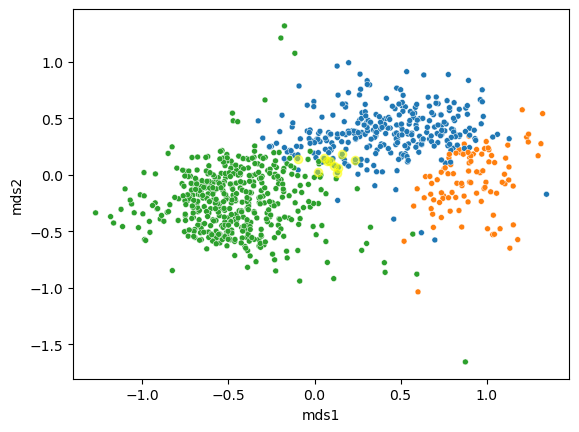

In [ ]:
sns.scatterplot(data=lamah_gdf, x="mds1", y="mds2",hue=strata_colors, legend=False, size=0.5)
plt.scatter(x=sep_mds_points[:,0], y=sep_mds_points[:,1], color="yellow", alpha=0.5)

#### Plot mds space

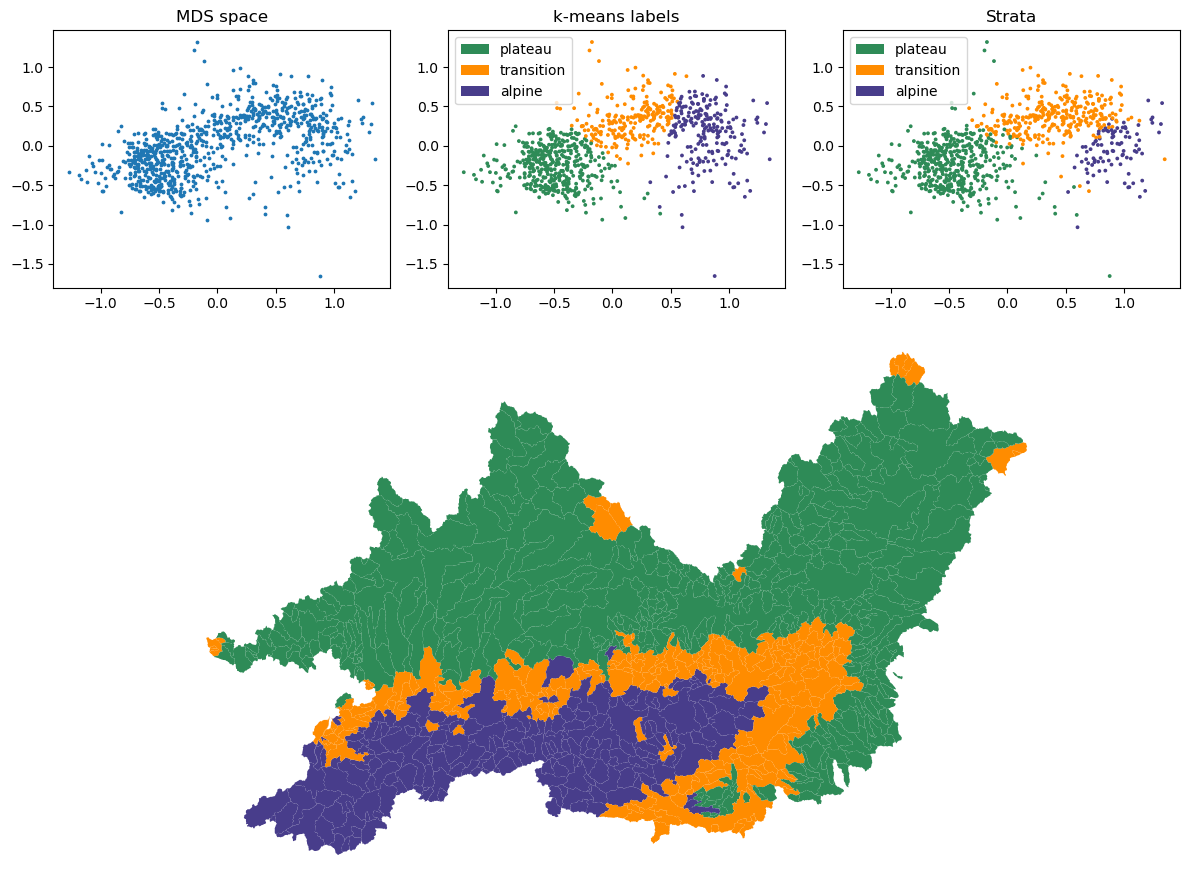

In [40]:
seed = seeds[np.where(s_scores[:,3] == Counter(s_scores[:,3]).most_common(1)[0][0])[0][0]] #235
k_means = KMeans(3, random_state=seed, max_iter=100)

fig, axs = plt.subplot_mosaic("ABC;DDD;DDD", figsize=(12,9))

cluster = k_means.fit_predict(array)

# 1. remap 
label_dict = {0: 2, 1: 0, 2: 1}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

# 3. colors
color_dict = {"plateau": "seagreen", "transition": "darkorange", "alpine": "darkslateblue"}
cluster_colors = list(map(lambda x: color_dict[x], cluster_named))
strata_colors = list(map(lambda x: color_dict[name_dict[x]], strata_ids["0"]))

# GDF
lamah_gdf["cluster"] = cluster_named

s = 3
plot_cell_state_2d(array, ax=axs["A"], title="MDS space", s=s) 
plot_cell_state_2d(array, ax=axs["B"], title="k-means labels", c=cluster_colors, s=s) 
plot_cell_state_2d(array, ax=axs["C"], title="Strata", c=strata_colors, s=s, label=strata_colors)

legend_elements = [
    Patch(facecolor="seagreen",      label="plateau"),
    Patch(facecolor="darkorange",    label="transition"),
    Patch(facecolor="darkslateblue", label="alpine"),
]

axs["B"].legend(handles=legend_elements, loc="upper left")
axs["C"].legend(handles=legend_elements, loc="upper left")

lamah_gdf.plot(ax=axs["D"], color=lamah_gdf["cluster"].map(color_dict))
axs["D"].axis("off")

plt.tight_layout()
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/mds_2d.png", dpi=300)

In [41]:
print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'], average='weighted')}")

jaccard score 0.737714051952144


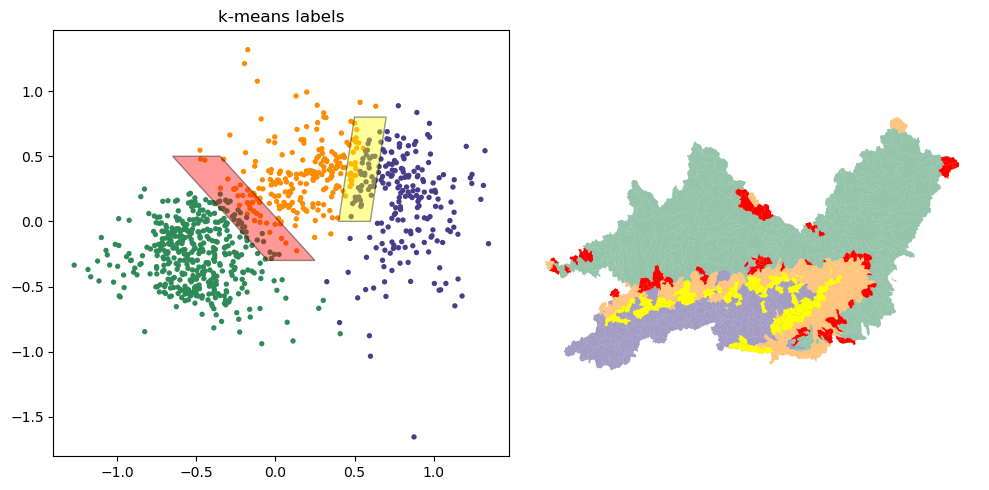

In [42]:
fig, axs = plt.subplot_mosaic("AB", figsize=(10,5))

plot_cell_state_2d(array, ax=axs["A"], title="k-means labels", c=cluster_colors, s=8) 

# Border plateau - transition
p1 = Polygon(xy=[(-0.65,0.5),(-0.35,0.5), (0.25,-0.3),(-0.05,-0.3)], facecolor="red", edgecolor="black", alpha=0.4)
axs["A"].add_patch(p1)
p2 = Polygon(xy=[(0.5,0.8),(0.7,0.8),(0.6,0.0), (0.4,0.0)], facecolor="yellow", edgecolor="black", alpha=0.4)
axs["A"].add_patch(p2)

border_basin_01_ids = lamah_gdf.index[p1.contains_points(p1.get_data_transform().transform(array))] 
border_basin_02_ids = lamah_gdf.index[p2.contains_points(p1.get_data_transform().transform(array))] 

lamah_gdf.plot(color=lamah_gdf["cluster"].map(color_dict), alpha=0.5,ax=axs["B"])
lamah_gdf.loc[border_basin_01_ids, :].plot(color="red", ax=axs["B"])
lamah_gdf.loc[border_basin_02_ids, :].plot(color="yellow", ax=axs["B"])
axs["B"].axis("off")

plt.tight_layout()
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/bordering_basins.png", dpi=300)

### Raw cell states

In [17]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p", "rb") as f: 
	raw_cell_states = pickle.load(f)

raw_cell_states = dict(sorted(raw_cell_states.items(), key=lambda item: int(item[0])))

In [18]:
r_cs_array = np.vstack([raw_cell_states[b]["c_mean"] for b in raw_cell_states.keys()])

100%|██████████| 100/100 [00:12<00:00,  7.95it/s]


Text(0.5, 1.0, 's_scores')

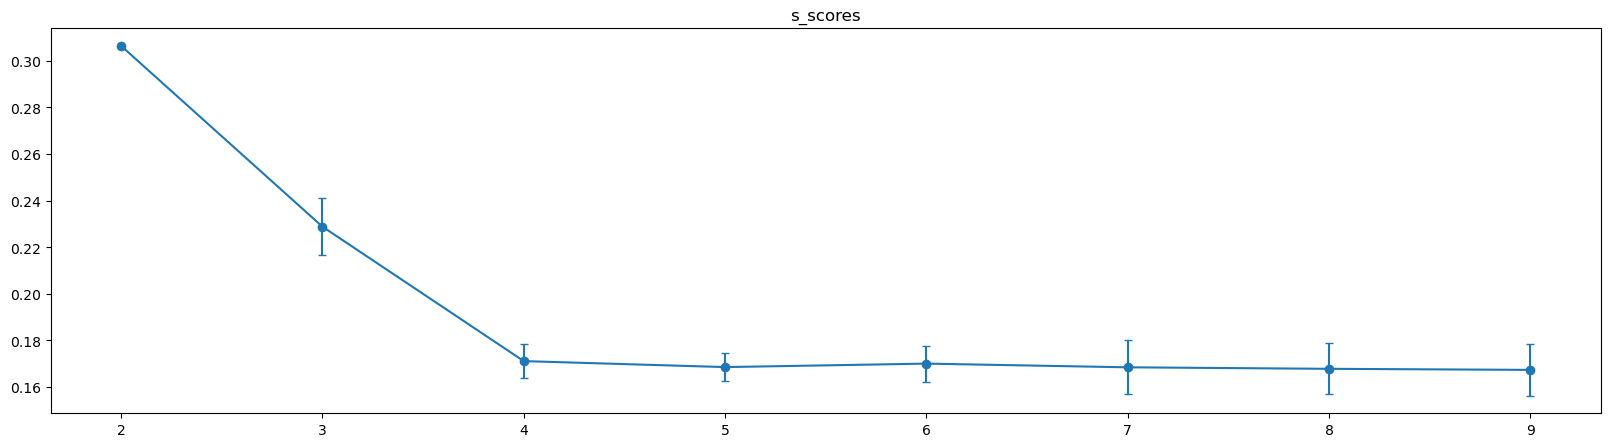

In [26]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores_2 = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(r_cs_array)
		s_scores_2[i,k] = silhouette_score(r_cs_array,labels) # higher is better
		
avg_s_scores_2 = s_scores_2.mean(axis=0)[2:]

std_s_scores_2 = s_scores_2.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores_2, yerr=std_s_scores_2, marker="o", capsize=3)

axs.set_title("s_scores")

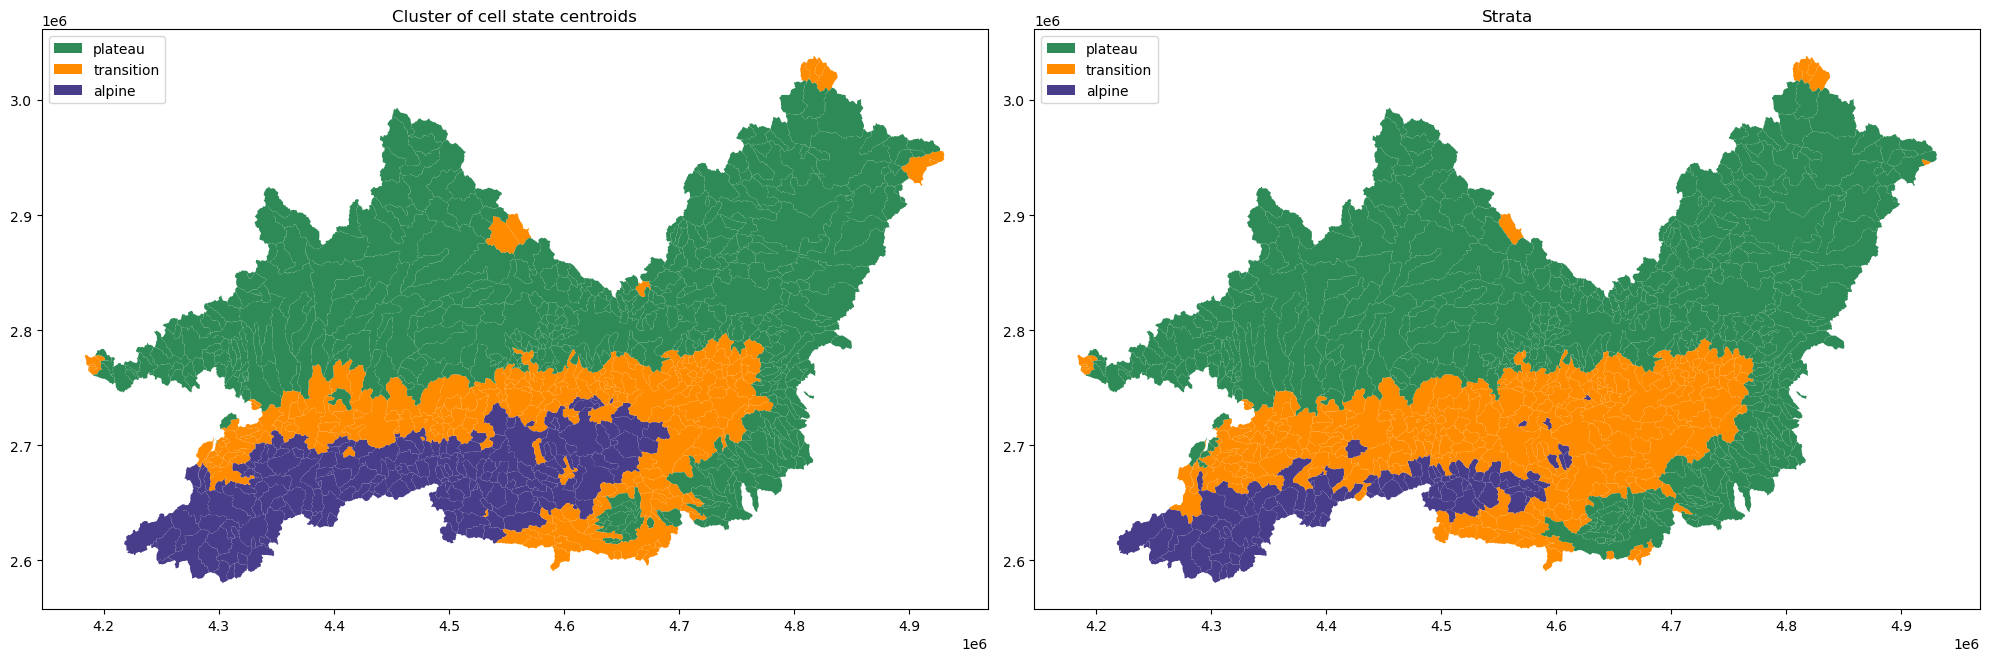

In [27]:
c = Counter(s_scores_2[:,3])

kmeans_seed = seeds[np.where(s_scores_2[:,3] == c.most_common(1)[0][0])[0][0]]

kmeans = KMeans(n_clusters=3, random_state=kmeans_seed, max_iter=100)

fig, axs = plt.subplots(1,2, figsize=(20,10))

cluster = kmeans.fit_predict(r_cs_array)

# 1. remap 
label_dict = {0: 0, 1: 2, 2: 1}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

lamah_gdf["cluster"] = cluster_named

lamah_gdf.plot(color=lamah_gdf["cluster"].map(color_dict), ax=axs[0], legend=True)
axs[0].set_title("Cluster of cell state centroids")
lamah_gdf.plot(color=strata_colors, ax=axs[1], legend=True)
axs[1].set_title("Strata")

axs[0].legend(handles=legend_elements, loc="upper left")
axs[1].legend(handles=legend_elements, loc="upper left")

plt.tight_layout()

fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CSA/cluster_centroids_strata_map.png", dpi=300)

In [28]:
print(f"jaccard score {jaccard_score(lamah_gdf['strata'], lamah_gdf['cluster'], average='weighted')}")

jaccard score 0.7704410139981576


### Compare Hydro IDS

In [16]:
var_total = numeric_hy_id.var(axis=0)
var_total

q_mean                      2.634759
runoff_ratio                0.101674
stream_elas                 0.311049
slope_fdc                   1.128463
baseflow_index_ladson       0.011168
baseflow_index_lfstat       0.019042
hfd_mean                 1035.771442
Q5                          0.171976
Q95                        25.851844
high_q_freq                72.467299
high_q_dur                  2.567420
low_q_freq               1095.097921
low_q_dur                 104.549884
zero_q_freq                 0.000120
dtype: float64

In [17]:
var_strata = numeric_hy_id.groupby(lamah_gdf.strata).mean().var().transpose()
var_strata

q_mean                   1.603047e+00
runoff_ratio             6.207143e-02
stream_elas              4.633972e-02
slope_fdc                8.244232e-01
baseflow_index_ladson    6.055523e-05
baseflow_index_lfstat    4.864813e-04
hfd_mean                 1.457573e+03
Q5                       6.096457e-02
Q95                      1.556215e+01
high_q_freq              7.508789e+00
high_q_dur               1.973953e-01
low_q_freq               4.753422e+02
low_q_dur                8.013682e+01
zero_q_freq              3.505937e-07
dtype: float64

In [18]:
frac_var_red_strata = 1 - var_strata/var_total

In [19]:
var_cluster = numeric_hy_id.groupby(lamah_gdf.cluster).mean().var().transpose()
var_cluster

q_mean                   1.547564e+00
runoff_ratio             5.493791e-02
stream_elas              3.181549e-02
slope_fdc                3.615593e-01
baseflow_index_ladson    4.409505e-04
baseflow_index_lfstat    1.613597e-03
hfd_mean                 1.188351e+03
Q5                       6.779784e-02
Q95                      1.290326e+01
high_q_freq              1.362839e+00
high_q_dur               1.420805e-01
low_q_freq               1.027914e+02
low_q_dur                2.556916e+01
zero_q_freq              4.346367e-07
dtype: float64

In [20]:
frac_var_red_cluster = 1 - var_cluster/var_total

In [21]:
frac_var_red_df = pd.DataFrame([frac_var_red_strata, frac_var_red_cluster]).T

In [22]:
frac_var_red_df

,0,1
q_mean,0.391577,0.412635
runoff_ratio,0.389508,0.459668
stream_elas,0.851021,0.897716
slope_fdc,0.269428,0.679600
baseflow_index_ladson,0.994578,0.960515
baseflow_index_lfstat,0.974452,0.915262
hfd_mean,-0.407234,-0.147310
Q5,0.645506,0.605772
Q95,0.398025,0.500877
high_q_freq,0.896384,0.981194


<Axes: ylabel='None'>

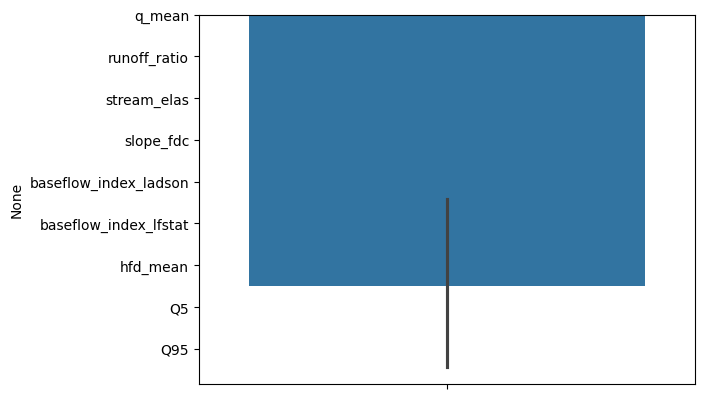

In [29]:
sns.barplot(frac_var_red_df, y=frac_var_red_df.index)

<Axes: xlabel='cluster'>

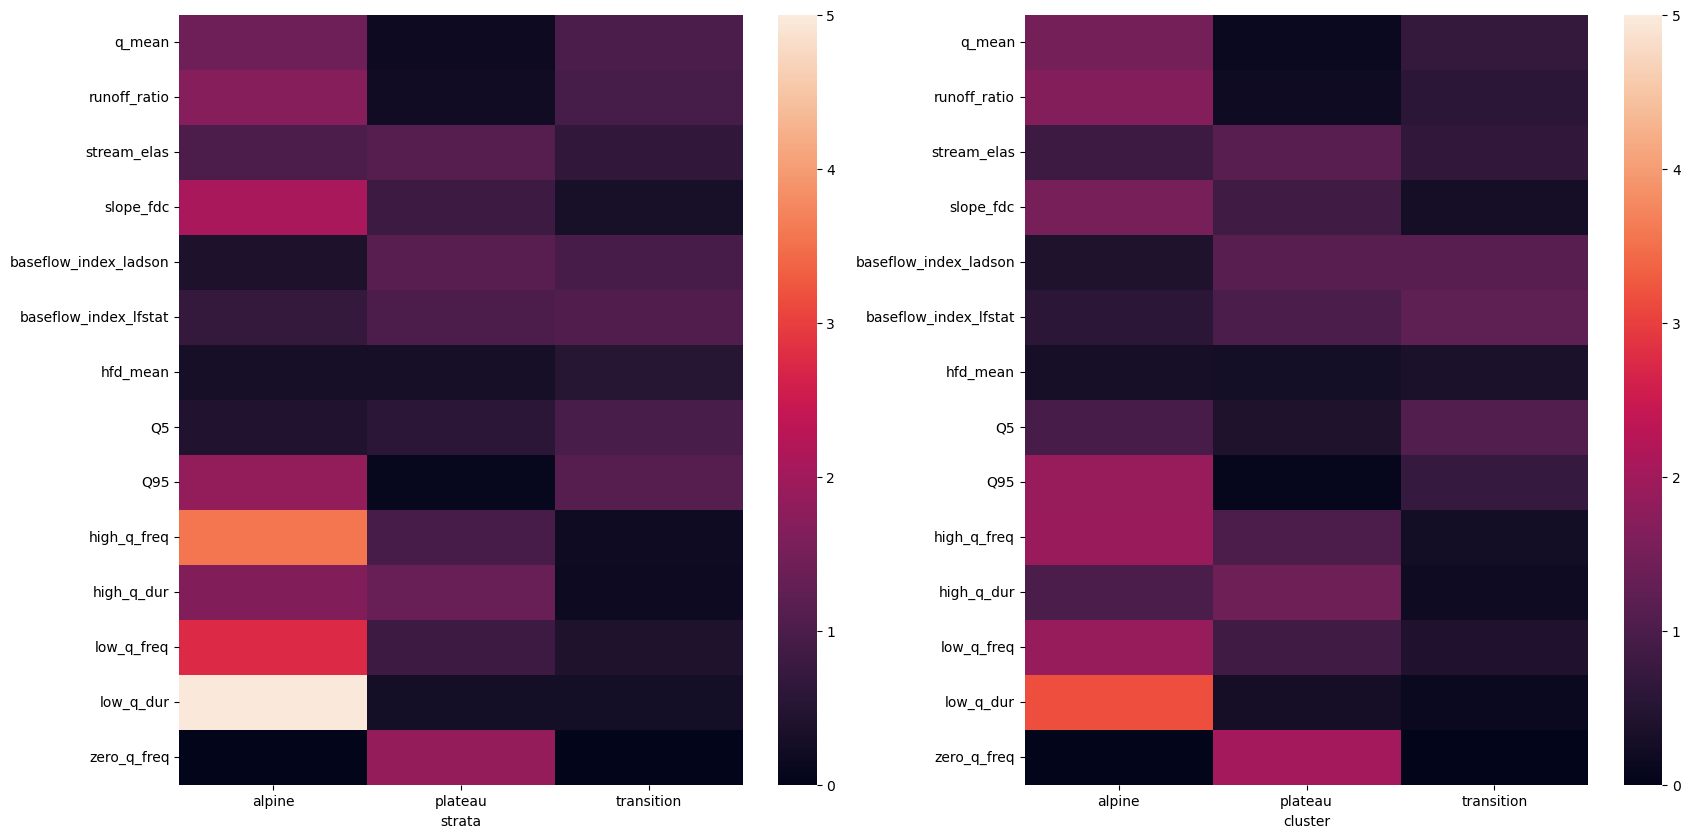

In [24]:
fig, axs = plt.subplots(1,2, figsize=(20,10))

sns.heatmap(ax=axs[0], data = scaled_hy_id.groupby(lamah_gdf.strata).var().transpose(),vmax=5)
sns.heatmap(ax=axs[1], data = scaled_hy_id.groupby(lamah_gdf["cluster"]).var().transpose(), vmax=5)

In [25]:
scaled_hy_id.groupby(lamah_gdf.cluster).var().transpose() - scaled_hy_id.groupby(lamah_gdf.strata).var().transpose()

cluster,alpine,plateau,transition
q_mean,0.074774,-0.055163,-0.284704
runoff_ratio,-0.017946,-0.040150,-0.352778
stream_elas,-0.227538,0.049895,0.007522
slope_fdc,-0.577865,0.043226,-0.050131
baseflow_index_ladson,0.010464,-0.025694,0.225639
baseflow_index_lfstat,-0.099109,-0.036575,0.161922
hfd_mean,0.001041,-0.022420,-0.150169
Q5,0.494474,-0.187408,0.091771
Q95,0.058277,-0.019307,-0.407842
high_q_freq,-1.645207,0.050528,0.052974


In [26]:
scaled_hy_id.groupby(lamah_gdf.cluster).mean().transpose().var(axis=1) - scaled_hy_id.groupby(lamah_gdf.strata).mean().transpose().var(axis=1) 

q_mean                  -0.021083
runoff_ratio            -0.070244
stream_elas             -0.046750
slope_fdc               -0.410660
baseflow_index_ladson    0.034103
baseflow_index_lfstat    0.059261
hfd_mean                -0.260234
Q5                       0.039781
Q95                     -0.102973
high_q_freq             -0.084911
high_q_dur              -0.021571
low_q_freq              -0.340603
low_q_dur               -0.522550
zero_q_freq              0.000701
dtype: float64